# Outras Funções Elementares

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano), [`0108a_funcao_quadratica_grafico_e_propriedades.ipynb`](0108a_funcao_quadratica_grafico_e_propriedades.ipynb) (gráfico de x², para comparação) e [`0110a_funcao_modular.ipynb`](0110a_funcao_modular.ipynb) (função definida por partes, gráficos com "quinas")

**Objetivos de aprendizagem:**
- Reconhecer e esboçar o gráfico de f(x) = x³, da raiz quadrada, da raiz cúbica e da função recíproca.
- Identificar domínio, imagem e principais características (crescimento, simetria, assíntotas) dessas funções.
- Reconhecer a função sinal, a função máximo inteiro e a função parte fracionária, e interpretar seus gráficos "em degraus".
- Relacionar cada função a pelo menos uma aplicação prática fora da matemática pura.

**Tempo estimado:** 40 a 55 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0111a_outras_funcoes_elementares.ipynb)

## Uma galeria de curvas misteriosas

Você já viu retas e parábolas em quantidade — chegou a hora de conhecer outros formatos. Antes de qualquer definição, olhe os quatro gráficos abaixo. Nenhum tem rótulo, nenhum tem legenda.

Você reconhece alguma dessas curvas? Uma delas, inclusive, você já usa **todo santo dia sem saber o nome**: toda vez que o preço de algo é arredondado para baixo, ou que um app mostra "3 itens" em vez de "3,7 itens", tem uma função destas por trás.

Matemática não é só reta e parábola. O mundo também tem curvas que "fogem para o infinito", curvas com cantos, e gráficos em forma de escada — e todas elas são tão úteis quanto as famosas. Ao longo deste notebook, cada uma dessas quatro curvas (e mais três primas próximas) vai ganhar nome, definição e aplicação.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def cubica(x):
    '''Calcula f(x) = x^3.'''
    return np.asarray(x, dtype=float) ** 3


def reciproca(x):
    '''Calcula f(x) = 1/x. Não é definida em x = 0.'''
    return 1.0 / np.asarray(x, dtype=float)


def sinal(x):
    '''Calcula a função sinal: -1 se x<0, 0 se x=0, 1 se x>0.'''
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, 1.0, np.where(x < 0, -1.0, 0.0))


def piso(x):
    '''Calcula a função máximo inteiro (piso): o maior inteiro <= x.'''
    return np.floor(np.asarray(x, dtype=float))


def fracionaria(x):
    '''Calcula a parte fracionária de x: {x} = x - piso(x).'''
    x = np.asarray(x, dtype=float)
    return x - piso(x)

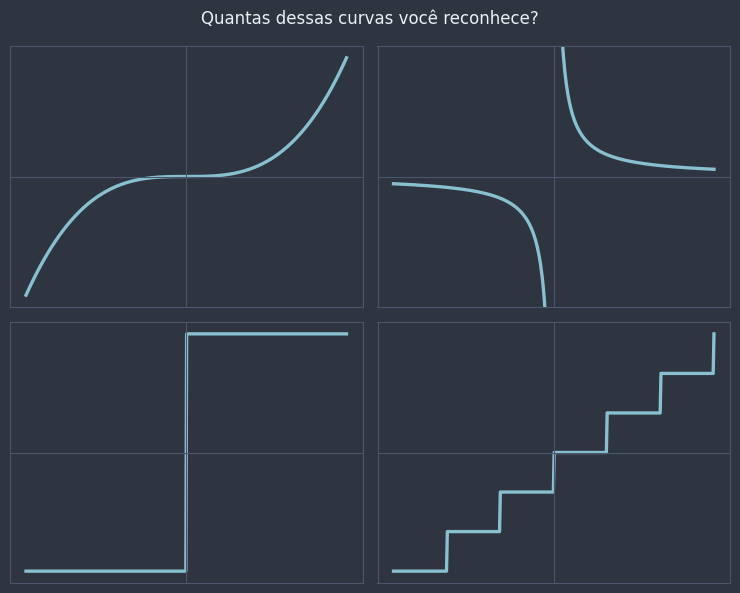

In [2]:
fig, eixos = plt.subplots(2, 2, figsize=(7.5, 6))
fig.patch.set_facecolor(NORD_FUNDO)

xs_misterio = np.linspace(-3, 3, 400)
xs_pos = np.linspace(0.15, 3, 200)
xs_neg = np.linspace(-3, -0.15, 200)

curvas_misterio = [
    (eixos[0][0], xs_misterio, cubica(xs_misterio), None),
    (eixos[0][1], None, None, "reciproca"),
    (eixos[1][0], xs_misterio, sinal(xs_misterio), None),
    (eixos[1][1], xs_misterio, piso(xs_misterio), None),
]

for ax, xs, ys, especial in curvas_misterio:
    estilizar_eixo(ax)
    if especial == "reciproca":
        ax.plot(xs_pos, reciproca(xs_pos), color=COR_PONTO, linewidth=2.4)
        ax.plot(xs_neg, reciproca(xs_neg), color=COR_PONTO, linewidth=2.4)
        ax.set_ylim(-6, 6)
    else:
        ax.plot(xs, ys, color=COR_PONTO, linewidth=2.4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

fig.suptitle("Quantas dessas curvas você reconhece?", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

Guarde essa imagem na memória — ao final do notebook vamos revê-la com todos os nomes revelados.

## 1. Função Cúbica: f(x) = x³

📌 **Definição:** f(x) = x³, com **domínio ℝ** e **imagem ℝ** — diferente da quadrática, aqui não há restrição de sinal: qualquer número real pode ser resultado.

Compare com x², já conhecida: x³ **preserva o sinal** de x (número positivo elevado ao cubo continua positivo; negativo continua negativo). Isso faz de f(x) = x³ uma **função ímpar**: f(-x) = -f(x), com simetria em relação à **origem** (não ao eixo y, como a parábola).

Outra diferença importante: x³ é **sempre crescente** em toda a reta real — não tem o trecho decrescente que a parábola tem antes do vértice.

- Wikipédia (PT): [Função cúbica](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_c%C3%BAbica)

,x,x^2,x^3
0,-3,9,-27.0
1,-2,4,-8.0
2,-1,1,-1.0
3,0,0,0.0
4,1,1,1.0
5,2,4,8.0
6,3,9,27.0


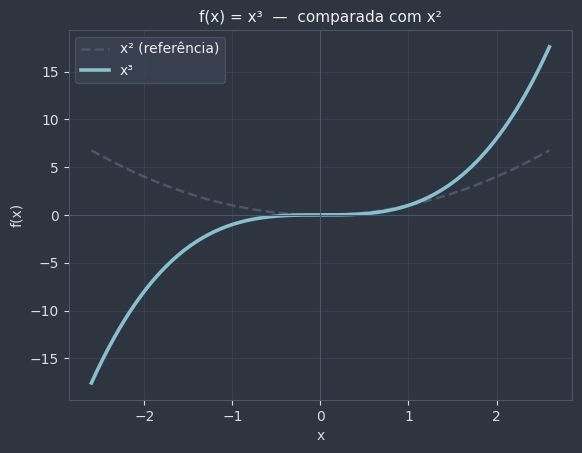

In [3]:
xs_cub_tab = np.arange(-3, 4)
tabela_cubica = pd.DataFrame({"x": xs_cub_tab, "x^2": xs_cub_tab**2, "x^3": cubica(xs_cub_tab)})
display(tabela_cubica)

xs_cub = np.linspace(-2.6, 2.6, 400)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_cub, xs_cub**2, color=NORD_LINHA, linewidth=1.8, linestyle="--", label="x² (referência)")
ax.plot(xs_cub, cubica(xs_cub), color=COR_PONTO, linewidth=2.6, label="x³")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = x³  —  comparada com x²", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
plt.show()

🕵️ **Curiosidade histórica:** a **duplicação do cubo** é um dos três problemas clássicos da Grécia Antiga (junto com a trissecção do ângulo e a quadratura do círculo): construir, apenas com régua e compasso, o lado de um cubo com o **dobro do volume** de um cubo dado. Foi provado, muitos séculos depois — já com ferramentas de álgebra que os gregos não tinham —, que isso é **impossível** com régua e compasso.

**Aplicação prática:** o volume de um objeto escala com o **cubo** da sua dimensão linear. Por isso um objeto duas vezes maior em cada lado tem **oito vezes** o volume (2³ = 8), não o dobro. É uma das razões pelas quais animais muito grandes não podem ter o mesmo formato de animais pequenos: a área da seção das patas cresce com o quadrado, mas o peso (ligado ao volume) cresce com o cubo — em algum ponto a estrutura não aguenta mais.

**Pergunta de checagem:**
- Sem calcular, (-2)³ é positivo ou negativo? E (-2)²?
- Por que o gráfico de x³ não tem simetria em relação ao eixo y, como o de x²?

## 2. Função Raiz Quadrada

📌 **Definição:** f(x) = √x. **Domínio:** x ≥ 0 (nos reais, não existe raiz quadrada de número negativo). **Imagem:** y ≥ 0.

A função é sempre crescente no domínio, mas de forma cada vez **mais lenta** — um crescimento desacelerado, bem diferente do crescimento constante de uma reta. Vale destacar isso visualmente: o gráfico "sobe rápido" perto de 0 e depois vai achatando.

📌 *Nota (sem desenvolver agora):* o gráfico de √x é, visualmente, "metade" do gráfico de x² deitado de lado. Essa relação será formalizada no próximo notebook, quando **função inversa** for definida.

- Wikipédia (PT): [Raiz quadrada](https://pt.wikipedia.org/wiki/Raiz_quadrada)

,x,sqrt(x)
0,0,0.0
1,1,1.0
2,4,2.0
3,9,3.0
4,16,4.0


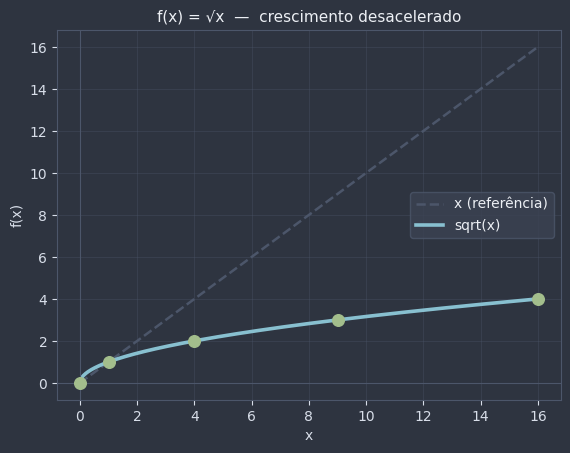

In [4]:
xs_raiz2_tab = np.array([0, 1, 4, 9, 16])
tabela_raiz2 = pd.DataFrame({"x": xs_raiz2_tab, "sqrt(x)": np.sqrt(xs_raiz2_tab)})
display(tabela_raiz2)

xs_raiz2 = np.linspace(0, 16, 400)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_raiz2, xs_raiz2, color=NORD_LINHA, linewidth=1.8, linestyle="--", label="x (referência)")
ax.plot(xs_raiz2, np.sqrt(xs_raiz2), color=COR_PONTO, linewidth=2.6, label="sqrt(x)")
ax.scatter(tabela_raiz2["x"], tabela_raiz2["sqrt(x)"], s=70, color=COR_DESTAQUE, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = √x  —  crescimento desacelerado", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
plt.show()

⚠️ **Erro comum:** achar que √x sempre dá dois resultados (positivo e negativo). Por definição, **√x (com esse símbolo, sem ± na frente) é sempre o valor não-negativo** — a chamada "raiz quadrada principal". A equação x² = 4 tem duas soluções (2 e -2), mas √4 é só 2.

**Aplicação prática:** fórmulas físicas com raiz quadrada aparecem o tempo todo — o tempo de queda livre de um objeto em função da altura, o período de um pêndulo simples, a velocidade de escape de um planeta. Por exemplo, o tempo (em segundos) para um objeto cair de uma altura h (em metros) é aproximadamente t = √(2h / 9,8): de uma altura de 20 m, t = √(40/9,8) ≈ 2,02 s.

**Pergunta de checagem:**
- Qual é o domínio de f(x) = √(x - 3)?
- Se x aumenta de 1 para 100, √x aumenta quantas vezes? E se x aumenta de 1 para 10.000?

## 3. Função Raiz Cúbica

📌 **Definição:** f(x) = ∛x. Diferente da raiz quadrada, aqui o **domínio é ℝ inteiro** — é possível tirar raiz cúbica de número negativo nos reais (∛(-8) = -2, pois (-2)³ = -8) — e a **imagem também é ℝ**.

É uma **função ímpar**, assim como x³ — mesma simetria em relação à origem.

📌 *Nota (sem desenvolver agora):* ∛x é o "espelho" de x³ em torno da reta y = x — mesma ideia de função inversa que será formalizada no próximo notebook.

- Wikipédia (PT): [Raiz cúbica](https://pt.wikipedia.org/wiki/Raiz_c%C3%BAbica)

,x,cbrt(x)
0,-8,-2.0
1,-1,-1.0
2,0,0.0
3,1,1.0
4,8,2.0


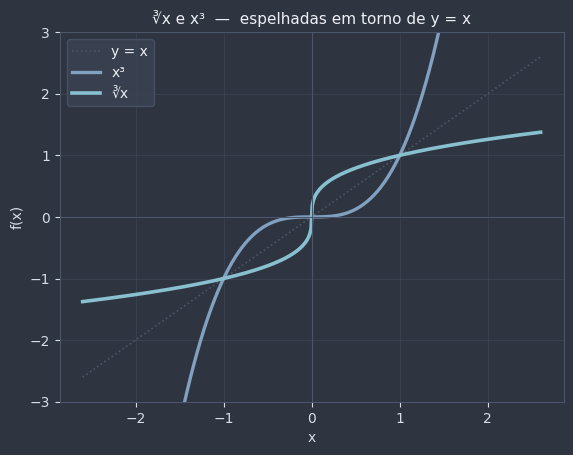

In [5]:
xs_raiz3_tab = np.array([-8, -1, 0, 1, 8])
tabela_raiz3 = pd.DataFrame({"x": xs_raiz3_tab, "cbrt(x)": np.cbrt(xs_raiz3_tab)})
display(tabela_raiz3)

xs_raiz3 = np.linspace(-2.6, 2.6, 400)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_raiz3, xs_raiz3, color=NORD_LINHA, linewidth=1.2, linestyle=":", label="y = x")
ax.plot(xs_raiz3, cubica(xs_raiz3), color=COR_SECUNDARIA, linewidth=2.4, label="x³")
ax.plot(xs_raiz3, np.cbrt(xs_raiz3), color=COR_PONTO, linewidth=2.6, label="∛x")
ax.set_ylim(-3, 3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("∛x e x³  —  espelhadas em torno de y = x", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
plt.show()

🕵️ **Curiosidade:** muito antes de qualquer calculadora existir, matemáticos já usavam **métodos de aproximação por tentativa e ajuste** para estimar raízes cúbicas — uma ideia parecida com o método babilônico, generalizada para outras raízes, refinando um "chute" inicial passo a passo até chegar bem perto do valor exato.

**Aplicação prática:** "engenharia reversa" do volume — dado o volume de um cubo ou de uma esfera, descobrir a medida linear correspondente. Exemplo: uma caixa cúbica de embalagem tem 64 cm³ de volume; o lado dela é ∛64 = 4 cm.

**Pergunta de checagem:**
- ∛(-27) é positivo, negativo ou não existe? Compare com √(-27).

## 4. Função Recíproca: f(x) = 1/x

📌 **Definição:** f(x) = 1/x. **Domínio:** todos os reais exceto x = 0. **Imagem:** todos os reais exceto y = 0.

📌 Uma ideia nova aparece aqui: a de **assíntota**. À medida que x se aproxima de 0, f(x) "explode" para +∞ ou -∞; à medida que x cresce ou decresce sem limite, f(x) se aproxima de 0 sem nunca tocar. Por enquanto vamos apenas **descrever esse comportamento visualmente** — a formalização com limites fica para o módulo 11.

A função é **ímpar** (mais uma vez, simetria pela origem) e seu gráfico tem dois "ramos" separados: um no primeiro quadrante (x > 0, f(x) > 0) e outro no terceiro (x < 0, f(x) < 0).

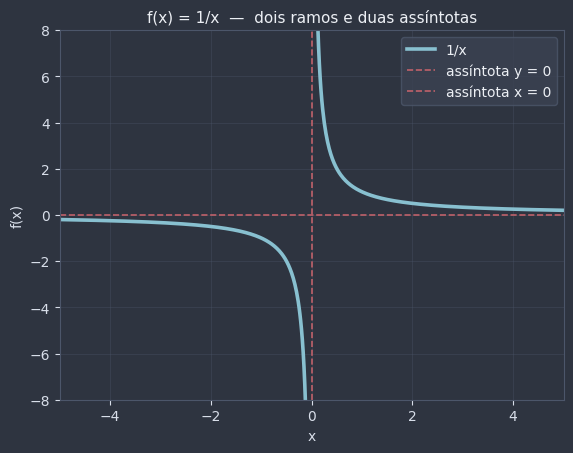

,x,f(x) = 1/x
0,1.000,1.0
1,0.100,10.0
2,0.010,100.0
3,0.001,1000.0


In [6]:
xs_rec_pos = np.linspace(0.12, 5, 300)
xs_rec_neg = np.linspace(-5, -0.12, 300)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_rec_pos, reciproca(xs_rec_pos), color=COR_PONTO, linewidth=2.6, label="1/x")
ax.plot(xs_rec_neg, reciproca(xs_rec_neg), color=COR_PONTO, linewidth=2.6)
ax.axhline(0, color=COR_ALERTA, linewidth=1.2, linestyle="--", label="assíntota y = 0")
ax.axvline(0, color=COR_ALERTA, linewidth=1.2, linestyle="--", label="assíntota x = 0")
ax.set_xlim(-5, 5)
ax.set_ylim(-8, 8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = 1/x  —  dois ramos e duas assíntotas", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
plt.show()

tabela_rec = pd.DataFrame({"x": [1, 0.1, 0.01, 0.001], "f(x) = 1/x": [1 / v for v in (1, 0.1, 0.01, 0.001)]})
display(tabela_rec)

🕹️ **Widget interativo:** mexa no slider e veja um ponto se aproximando de x = 0 pela direita sobre a curva 1/x — repare como f(x) cresce cada vez mais rápido, sem nunca "chegar" a um valor final. É a assíntota vertical em ação.

In [7]:
def explorar_reciproca(x: float) -> None:
    xs = np.linspace(0.05, 5, 300)

    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, reciproca(xs), color=COR_PONTO, linewidth=2.4)
    ax.axhline(0, color=COR_ALERTA, linewidth=1, linestyle="--")
    ax.axvline(0, color=COR_ALERTA, linewidth=1, linestyle="--")
    ax.scatter([x], [1 / x], s=100, color=COR_DESTAQUE, zorder=4)
    ax.set_xlim(-0.3, 5)
    ax.set_ylim(-1, 25)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"x = {x:.4f}  ->  f(x) = 1/x = {1 / x:.2f}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_reciproca,
    x=widgets.FloatLogSlider(value=1.0, base=10, min=-3, max=0.6, step=0.05, description="x:"),
)

interactive(children=(FloatLogSlider(value=1.0, description='x:', max=0.6, min=-3.0, step=0.05), Output()), _d…

<function __main__.explorar_reciproca(x: float) -> None>

📌 **Nota:** o gráfico de 1/x é uma **hipérbole equilátera** — será retomado com mais detalhe em Geometria Analítica (módulo 07), quando as cônicas forem estudadas formalmente.

🕵️ **Curiosidade histórica:** curvas com assíntotas já eram estudadas por **Apolônio de Perga**, na Grécia Antiga, muitos séculos antes de o conceito de limite ser formalizado no cálculo.

**Aplicação prática:** a Lei de Boyle, da física, diz que pressão × volume = constante (a temperatura fixa) — dobrar a pressão sobre um gás reduz o volume à metade. O mesmo formato de curva aparece em resistores em paralelo e na equação de lentes em óptica.

**Pergunta de checagem:**
- Por que 1/x nunca pode valer 0, para nenhum x do domínio?
- O que acontece com f(x) = 1/x quando x é um número negativo muito próximo de zero (ex: x = -0,001)?

- Wikipédia (PT): [Hipérbole](https://pt.wikipedia.org/wiki/Hip%C3%A9rbole)

## 5. Função Sinal (sgn)

Até aqui, todo gráfico deste notebook foi uma curva contínua — sem "buracos" nem "saltos". Isso muda a partir de agora: as próximas três funções têm gráficos com **saltos**, e essa mudança de comportamento merece atenção.

📌 **Definição por partes:**

$$\text{sgn}(x) = \begin{cases} -1, & x < 0 \\ 0, & x = 0 \\ 1, & x > 0 \end{cases}$$

**Domínio:** ℝ. **Imagem:** {-1, 0, 1} — apenas três valores possíveis, bem diferente de tudo visto até aqui.

- Wikipédia (PT): [Função sinal](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_sinal)

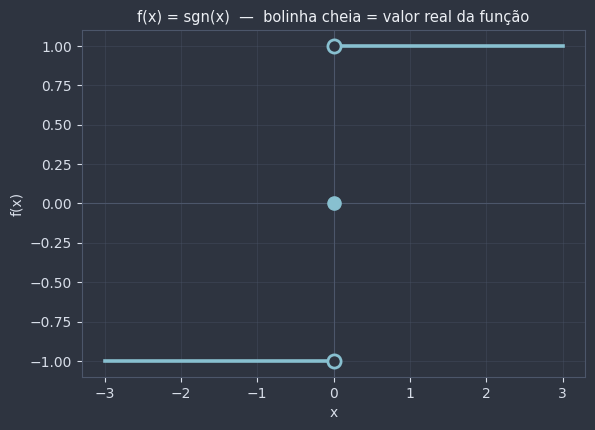

sgn(-5) = -1   (confere com numpy.sign: -1)
sgn(-0.1) = -1   (confere com numpy.sign: -1)
sgn(0) = 0   (confere com numpy.sign: 0)
sgn(0.1) = 1   (confere com numpy.sign: 1)
sgn(5) = 1   (confere com numpy.sign: 1)


In [8]:
xs_sgn = np.linspace(-3, 3, 400)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_sgn[xs_sgn < 0], sinal(xs_sgn[xs_sgn < 0]), color=COR_PONTO, linewidth=2.6)
ax.plot(xs_sgn[xs_sgn > 0], sinal(xs_sgn[xs_sgn > 0]), color=COR_PONTO, linewidth=2.6)
# bolinha fechada em (0, 0): o valor que a função REALMENTE assume em x=0
ax.scatter([0], [0], s=90, color=COR_PONTO, zorder=4)
# bolinhas abertas: valores que a curva "quase" toca, mas não assume, em x=0
ax.scatter([0], [1], s=90, facecolor=NORD_FUNDO, edgecolor=COR_PONTO, linewidth=2, zorder=4)
ax.scatter([0], [-1], s=90, facecolor=NORD_FUNDO, edgecolor=COR_PONTO, linewidth=2, zorder=4)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = sgn(x)  —  bolinha cheia = valor real da função", color=NORD_TEXTO, fontsize=10.5)
plt.show()

for valor in (-5, -0.1, 0, 0.1, 5):
    print(f"sgn({valor}) = {sinal(valor):g}   (confere com numpy.sign: {np.sign(valor):g})")

⚠️ **Erro comum:** achar que sgn(0) é indefinido, ou que vale 1 ou -1 "por convenção". Por **definição**, sgn(0) = 0 — é exatamente por isso que a bolinha em x=0 aparece **cheia** na altura 0, e **vazia** nas alturas 1 e -1 (valores que a função se aproxima, mas não assume, em x=0).

**Aplicação prática:** sistemas de controle liga/desliga, como termostatos ("bang-bang control"), e funções de ativação simples em redes neurais elementares — decidir "para qual lado empurrar" sem se importar com a intensidade.

**Pergunta de checagem:**
- Qual é a imagem da função sinal? Ela pode assumir, por exemplo, o valor 0,5?

## 6. Função Máximo Inteiro (função piso)

📌 **Definição:** ⌊x⌋ (também escrito [x]) é o **maior número inteiro menor ou igual a x**. Também chamada de "função piso" (floor function).

**Domínio:** ℝ. **Imagem:** ℤ (o conjunto dos números inteiros).

O gráfico tem formato de **escada**: em cada intervalo [n, n+1), a função vale exatamente n — um trecho horizontal constante, seguido de um salto vertical no próximo inteiro.

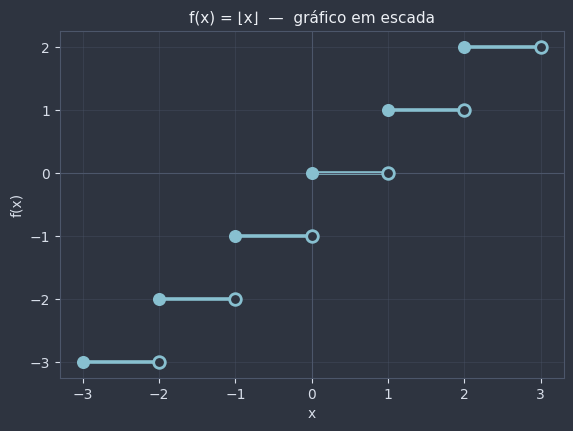

,x,piso(x)
0,-1.5,-2.0
1,-0.3,-1.0
2,0.0,0.0
3,1.9,1.0
4,2.9,2.0
5,3.0,3.0


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for n in range(-3, 3):
    ax.plot([n, n + 1], [n, n], color=COR_PONTO, linewidth=2.6, zorder=2)
    ax.scatter([n], [n], s=70, color=COR_PONTO, zorder=3)
    ax.scatter([n + 1], [n], s=70, facecolor=NORD_FUNDO, edgecolor=COR_PONTO, linewidth=2, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = ⌊x⌋  —  gráfico em escada", color=NORD_TEXTO, fontsize=11)
plt.show()

xs_piso_tab = np.array([-1.5, -0.3, 0, 1.9, 2.9, 3])
tabela_piso = pd.DataFrame({"x": xs_piso_tab, "piso(x)": piso(xs_piso_tab)})
display(tabela_piso)

⚠️ **Erro comum:** achar que ⌊-1,5⌋ = -1 (arredondamento comum, para o inteiro mais próximo). O piso é sempre o inteiro **imediatamente abaixo ou igual**, nunca "o mais próximo" — por isso ⌊-1,5⌋ = **-2**, e não -1.

🕵️ **Curiosidade histórica:** a notação [x] foi introduzida por **Gauss**. Hoje o símbolo ⌊x⌋ (colchetes de piso) é o mais usado, para diferenciar de "máximo inteiro" genérico e de funções relacionadas, como o **teto** (⌈x⌉, o menor inteiro maior ou igual a x).

**Aplicação prática:** cobrança de estacionamento por hora cheia iniciada, quantização de sinais digitais/áudio, e as funções `int()` e `math.floor()`.

**Pergunta de checagem:**
- Quanto vale ⌊4⌋? E ⌊4,9⌋? E ⌊-0,3⌋?
- Por que o gráfico de ⌊x⌋ nunca "sobe" continuamente, só em saltos?

## 7. Função Parte Fracionária

📌 **Definição:** {x} = x - ⌊x⌋ — o que "sobra" de x depois de tirar sua parte inteira **pelo piso** (não por truncamento simples, então funciona também para negativos).

**Domínio:** ℝ. **Imagem:** [0, 1) — nunca chega a valer 1, sempre reinicia em 0.

O gráfico tem formato de **dente de serra**: sobe de 0 até quase 1 dentro de cada intervalo [n, n+1) e depois volta a 0 bruscamente.

- Wikipédia (PT): [Parte fracionária](https://pt.wikipedia.org/wiki/Parte_fracion%C3%A1ria)

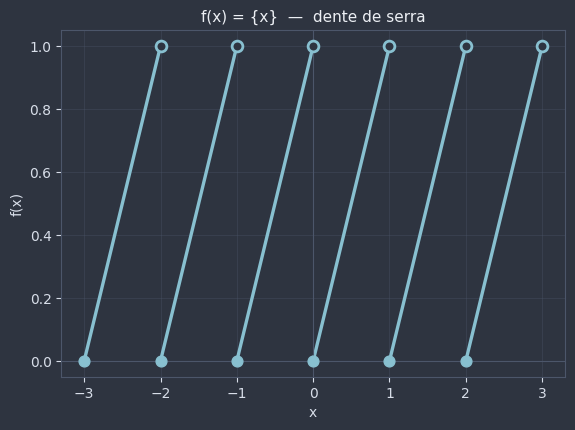

{2.7} = 2.7 - piso(2.7) = 2.7 - (2) = 0.7
{-1.3} = -1.3 - piso(-1.3) = -1.3 - (-2) = 0.7


In [10]:
xs_frac = np.linspace(-3, 3, 600)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for n in range(-3, 3):
    trecho = (xs_frac >= n) & (xs_frac < n + 1)
    ax.plot(xs_frac[trecho], fracionaria(xs_frac[trecho]), color=COR_PONTO, linewidth=2.4, zorder=2)
    ax.scatter([n], [0], s=60, color=COR_PONTO, zorder=3)
    ax.scatter([n + 1], [1], s=60, facecolor=NORD_FUNDO, edgecolor=COR_PONTO, linewidth=2, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = {x}  —  dente de serra", color=NORD_TEXTO, fontsize=11)
plt.show()

for valor in (2.7, -1.3):
    print(f"{{{valor}}} = {valor} - piso({valor}) = {valor} - ({piso(valor):g}) = {fracionaria(valor):.1f}")

📌 **Conexão:** o padrão repetitivo do "dente de serra" antecipa, de forma informal, a ideia de **função periódica** — será formalizada com seno e cosseno no módulo de Trigonometria.

**Aplicação prática:** geração de ondas dente de serra em síntese de áudio, e geradores simples de números pseudoaleatórios (que multiplicam um valor e pegam só a parte fracionária do resultado).

**Pergunta de checagem:**
- Quanto vale {5}? E {-0,5}?
- Por que a imagem de {x} nunca inclui o valor 1?

## Resumo — cheat sheet

| Função | Domínio | Imagem | Observação |
|---|---|---|---|
| x³ | ℝ | ℝ | ímpar, sempre crescente |
| √x | x ≥ 0 | y ≥ 0 | sempre não-negativa, crescimento desacelerado |
| ∛x | ℝ | ℝ | ímpar, sempre crescente |
| 1/x | x ≠ 0 | y ≠ 0 | ímpar, assíntotas em x=0 e y=0 |
| sgn(x) | ℝ | {-1, 0, 1} | descontínua, só 3 valores |
| ⌊x⌋ | ℝ | ℤ | descontínua, gráfico em degraus |
| {x} | ℝ | [0, 1) | descontínua, gráfico em dente de serra |

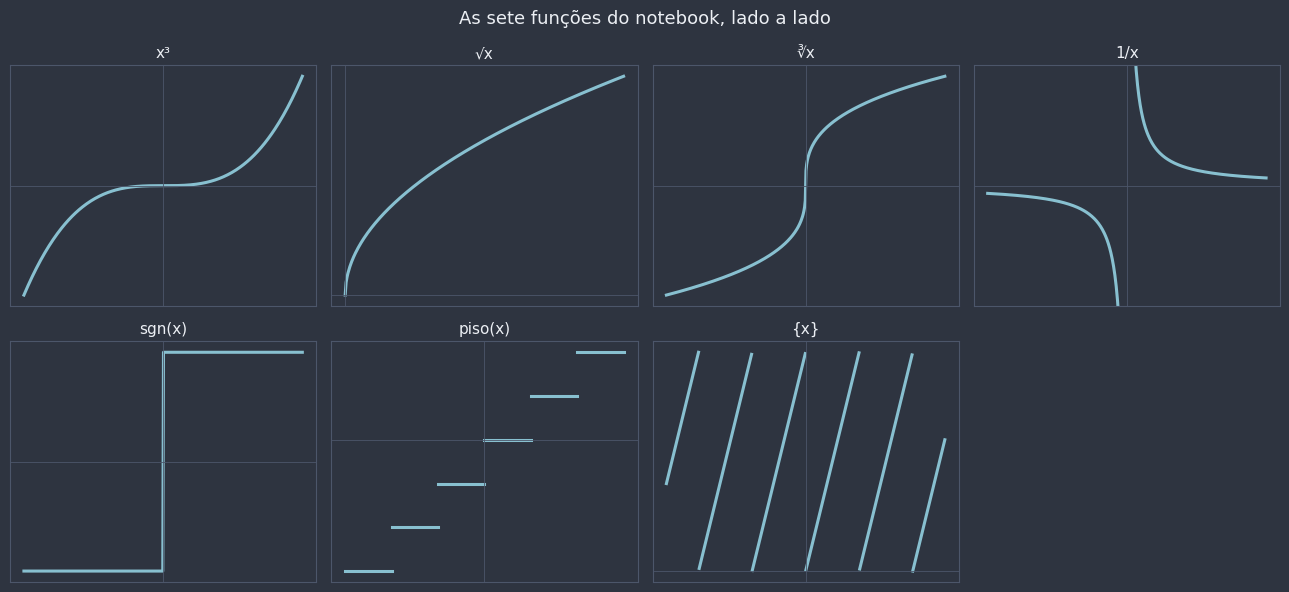

In [11]:
fig, eixos = plt.subplots(2, 4, figsize=(13, 6))
fig.patch.set_facecolor(NORD_FUNDO)

xs_galeria = np.linspace(-2.6, 2.6, 400)
xs_galeria_pos = np.linspace(0.15, 2.6, 200)
xs_galeria_neg = np.linspace(-2.6, -0.15, 200)
xs_raiz_galeria = np.linspace(0, 6, 300)

especificacoes = [
    ("x³", lambda ax: ax.plot(xs_galeria, cubica(xs_galeria), color=COR_PONTO, linewidth=2.2)),
    ("√x", lambda ax: ax.plot(xs_raiz_galeria, np.sqrt(xs_raiz_galeria), color=COR_PONTO, linewidth=2.2)),
    ("∛x", lambda ax: ax.plot(xs_galeria, np.cbrt(xs_galeria), color=COR_PONTO, linewidth=2.2)),
    (
        "1/x",
        lambda ax: (
            ax.plot(xs_galeria_pos, reciproca(xs_galeria_pos), color=COR_PONTO, linewidth=2.2),
            ax.plot(xs_galeria_neg, reciproca(xs_galeria_neg), color=COR_PONTO, linewidth=2.2),
            ax.set_ylim(-6, 6),
        ),
    ),
    ("sgn(x)", lambda ax: ax.plot(xs_galeria, sinal(xs_galeria), color=COR_PONTO, linewidth=2.2)),
    ("piso(x)", lambda ax: [ax.plot([n, n + 1], [n, n], color=COR_PONTO, linewidth=2.2) for n in range(-3, 3)]),
    (
        "{x}",
        lambda ax: [
            ax.plot(
                xs_galeria[(xs_galeria >= n) & (xs_galeria < n + 1)],
                fracionaria(xs_galeria[(xs_galeria >= n) & (xs_galeria < n + 1)]),
                color=COR_PONTO,
                linewidth=2.2,
            )
            for n in range(-3, 3)
        ],
    ),
]

eixos_flat = eixos.flatten()
for ax, (nome, desenhar) in zip(eixos_flat, especificacoes):
    estilizar_eixo(ax)
    desenhar(ax)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.6)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(nome, color=NORD_TEXTO, fontsize=11)

eixos_flat[-1].axis("off")

fig.suptitle("As sete funções do notebook, lado a lado", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

## Exercícios

**Básico**
1. Calcule f(2) para cada uma das sete funções estudadas.
2. Identifique o domínio de f(x) = 1/(x-4) e de g(x) = √(x+5).

**Intermediário**
3. Associe cada gráfico sem rótulo (A, B, C, D) à função correta.
4. Calcule ⌊7,8⌋, ⌊-2,1⌋, {7,8} e {-2,1}.

**Desafio**
5. Determine o domínio de f(x) = √x + 1/(x-2).
6. Modele o custo de um estacionamento que cobra R$5 por hora ou fração.

### Básico

In [ ]:
# Exercício Básico 1: calcule f(2) para cada uma das sete funções, na ordem
# cubica, raiz quadrada, raiz cubica, reciproca, sinal, piso, fracionaria.
# Preencha valores_ex1 com uma lista de 7 números, nessa ordem.
valores_ex1 = ...

print(valores_ex1)

In [ ]:
# Verificação
gabarito_ex1 = [8, math.sqrt(2), float(np.cbrt(2)), 0.5, 1, 2, 0]
assert len(valores_ex1) == 7 and all(
    math.isclose(v, g, rel_tol=1e-6) for v, g in zip(valores_ex1, gabarito_ex1)
), (
    "Tente de novo, revise o passo 1: aplique cada função em x=2, na ordem "
    "cubica, raiz quadrada, raiz cubica, reciproca, sinal, piso, fracionaria "
    "(seções 1 a 7)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: identifique o domínio de f(x) = 1/(x-4) e de
# g(x) = sqrt(x+5). Preencha excluido_ex2 (valor de x que NÃO pode entrar em
# f) e minimo_ex2 (menor valor de x que PODE entrar em g).
excluido_ex2 = ...
minimo_ex2 = ...

print(excluido_ex2, minimo_ex2)

In [ ]:
# Verificação
assert excluido_ex2 == 4, (
    "Tente de novo, revise o passo 1: 1/(x-4) não é definida quando o "
    "denominador é 0 (seção 4 - Função recíproca)."
)
assert minimo_ex2 == -5, (
    "Tente de novo, revise o passo 2: sqrt(x+5) exige x+5 >= 0 (seção 2 - "
    "Função raiz quadrada)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: os quatro gráficos abaixo (A, B, C, D) mostram
# quatro das sete funções estudadas, sem rótulo. Preencha associacao_ex3 com
# uma lista de 4 strings, na ordem A, B, C, D, usando os nomes:
# "cubica", "raiz_quadrada", "raiz_cubica", "reciproca", "sinal", "piso",
# "fracionaria".
fig, eixos = plt.subplots(1, 4, figsize=(12, 3))
fig.patch.set_facecolor(NORD_FUNDO)

xs_ex3 = np.linspace(-2.6, 2.6, 400)
xs_ex3_pos = np.linspace(0.15, 2.6, 200)
xs_ex3_neg = np.linspace(-2.6, -0.15, 200)

for ax in eixos:
    estilizar_eixo(ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axhline(0, color=NORD_LINHA, linewidth=0.6)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.6)

eixos[0].plot(xs_ex3, fracionaria(xs_ex3), color=COR_PONTO, linewidth=2.2)
eixos[0].set_title("A", color=NORD_TEXTO)

for n in range(-3, 3):
    eixos[1].plot([n, n + 1], [n, n], color=COR_PONTO, linewidth=2.2)
eixos[1].set_title("B", color=NORD_TEXTO)

eixos[2].plot(xs_ex3, cubica(xs_ex3), color=COR_PONTO, linewidth=2.2)
eixos[2].set_title("C", color=NORD_TEXTO)

eixos[3].plot(xs_ex3_pos, reciproca(xs_ex3_pos), color=COR_PONTO, linewidth=2.2)
eixos[3].plot(xs_ex3_neg, reciproca(xs_ex3_neg), color=COR_PONTO, linewidth=2.2)
eixos[3].set_ylim(-6, 6)
eixos[3].set_title("D", color=NORD_TEXTO)

plt.tight_layout()
plt.show()

associacao_ex3 = ...

print(associacao_ex3)

In [ ]:
# Verificação
assert associacao_ex3 == ["fracionaria", "piso", "cubica", "reciproca"], (
    "Tente de novo, revise o formato dos degraus (piso e fracionaria, seções "
    "6 e 7), a curva ímpar sem quinas (cubica, seção 1) e os dois ramos com "
    "assíntotas (reciproca, seção 4)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: calcule floor(7.8), floor(-2.1), frac(7.8) e
# frac(-2.1). Preencha as quatro variáveis abaixo.
piso_78_ex4 = ...
piso_neg21_ex4 = ...
frac_78_ex4 = ...
frac_neg21_ex4 = ...

print(piso_78_ex4, piso_neg21_ex4, frac_78_ex4, frac_neg21_ex4)

In [ ]:
# Verificação
assert (piso_78_ex4, piso_neg21_ex4) == (7, -3), (
    "Tente de novo, revise o passo 1: piso é sempre o inteiro imediatamente "
    "ABAIXO ou igual, mesmo para negativos (seção 6 - Função máximo inteiro)."
)
assert abs(frac_78_ex4 - 0.8) < 1e-9 and abs(frac_neg21_ex4 - 0.9) < 1e-9, (
    "Tente de novo, revise o passo 2: {x} = x - piso(x). Para x=-2.1, "
    "piso(x)=-3, então {x} = -2.1 - (-3) = 0.9 (seção 7 - Parte fracionária)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: determine o domínio de f(x) = sqrt(x) + 1/(x-2), que
# combina duas restrições (a da raiz quadrada e a da recíproca). Preencha
# minimo_ex5 (menor valor aceito, pela raiz) e excluido_ex5 (valor que deve
# ser excluído, pela recíproca).
minimo_ex5 = ...
excluido_ex5 = ...

print(minimo_ex5, excluido_ex5)

In [ ]:
# Verificação
assert minimo_ex5 == 0, (
    "Tente de novo, revise o passo 1: sqrt(x) exige x >= 0 (seção 2)."
)
assert excluido_ex5 == 2, (
    "Tente de novo, revise o passo 2: 1/(x-2) exige x != 2 (seção 4)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: o estacionamento cobra R$5 por hora ou fração — ou
# seja, qualquer fração de hora iniciada já conta como uma hora cheia
# (arredondamento para CIMA, e não para baixo como o piso). Complete
# custo_estacionamento usando math.ceil (a função "teto", prima do piso
# visto na seção 6).
def custo_estacionamento(horas: float) -> float:
    '''Calcula o custo (em R$) de horas de estacionamento, a R$5 por hora ou fração.'''
    ...


print(custo_estacionamento(1.2), custo_estacionamento(3), custo_estacionamento(0.5))

In [ ]:
# Verificação
assert custo_estacionamento(1.2) == 10, (
    "Tente de novo, revise o passo 1: 1,2 h iniciou uma segunda hora -> "
    "cobra 2 horas cheias (seção 6 - função piso e sua prima, a função teto)."
)
assert custo_estacionamento(3) == 15, (
    "Tente de novo, revise o passo 2: 3 h exatas -> cobra exatamente 3 "
    "horas, sem fração extra."
)
assert custo_estacionamento(0.5) == 5, (
    "Tente de novo, revise o passo 3: qualquer fração de hora já conta como "
    "uma hora cheia."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano)
- [`0108a_funcao_quadratica_grafico_e_propriedades.ipynb`](0108a_funcao_quadratica_grafico_e_propriedades.ipynb) (gráfico de x², usado como referência de comparação)
- [`0110a_funcao_modular.ipynb`](0110a_funcao_modular.ipynb) (função definida por partes)

**Isso será usado em:**
- [`0112a_transformacoes_composta_e_inversa.ipynb`](0112a_transformacoes_composta_e_inversa.ipynb) (raiz quadrada/cúbica como inversas de x² e x³, formalizado ali)
- [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (a recíproca como hipérbole equilátera, cônicas)
- [`05_trigonometria/`](../05_trigonometria/) (periodicidade, antecipada pela função parte fracionária)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (descontinuidade de sinal/máximo inteiro/parte fracionária revisitada formalmente, e o comportamento assintótico da recíproca)